In [13]:
library(ggplot2)
library(data.table)


Attaching package: ‘data.table’


The following object is masked from ‘package:SummarizedExperiment’:

    shift


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second




In [10]:
tmp = readRDS('haem_full_landscape.rds')

In [21]:
tmp2 = as.data.table(colData(tmp))

In [15]:
io = list()
io$biomart = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt'
biomart = fread(io$biomart)[match(rownames(tmp), ens_id)]
rownames(tmp) = biomart$symbol

In [22]:
head(tmp2)

cell,Dim1,Dim2,sample,stage,stage.mapped,stage.collapsed,stage.mapped.collapsed,somite_count,tube_name,tube_name_corrected,celltype,celltype.extended,celltype.descendant,celltype.descendant.somites,doub.density,cluster,cluster.sub,celltype.clustering
<fct>,<dbl>,<dbl>,<int>,<fct>,<fct>,<chr>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>
cell_1,-130760.95,-270247.8,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,0.0431142,7,5,Epiblast
cell_2,-93729.95,-238277.3,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Primitive Streak,Primitive Streak,Primitive Streak,Primitive Streak,1.1297133,7,6,Primitive Streak
cell_6,-139989.11,-261690.0,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,1.2547088,7,2,Epiblast
cell_8,-139573.60,-265925.3,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,1.3457586,7,1,Epiblast
cell_9,-132722.06,-271136.4,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,1.1463686,7,1,Epiblast
cell_10,-130816.86,-258119.0,1,E6.5,E6.5,E6.5,E6.5,Undetermined,Undetermined,Undetermined,Epiblast,Epiblast,Epiblast,Epiblast,0.0000000,7,7,Epiblast


In [55]:
plot_gene = function(gene){
    tmp2$gene = as.vector(logcounts(tmp[gene,]))
    tmp2 = tmp2[order(gene)]
    head(tmp2)
    ggplot(tmp2, aes(Dim1, Dim2, color = gene)) +
        geom_point() +
        viridis::scale_color_viridis(name = 'Logcount') + 
        ggtitle(gene) + 
        coord_fixed() + 
        theme_void() + 
        theme(plot.title = element_text(size = 25, hjust = 0.5),
              legend.text = element_text(size = 15),
              legend.title = element_text(size = 20, hjust = 0),
              legend.position = c(0.15, 0.85))
}

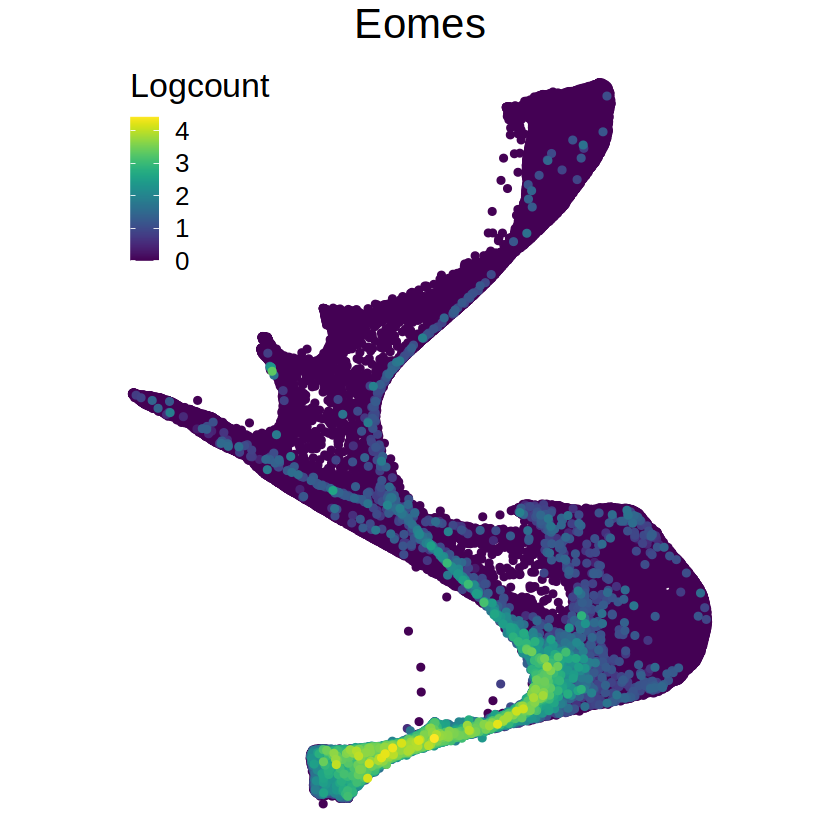

In [56]:
plot_gene('Eomes')


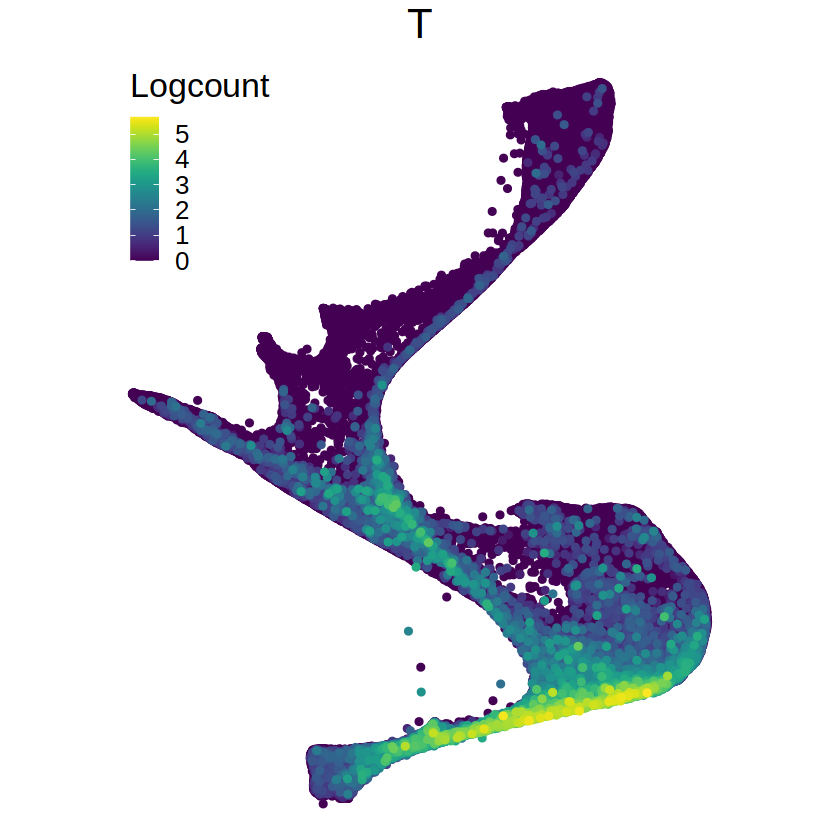

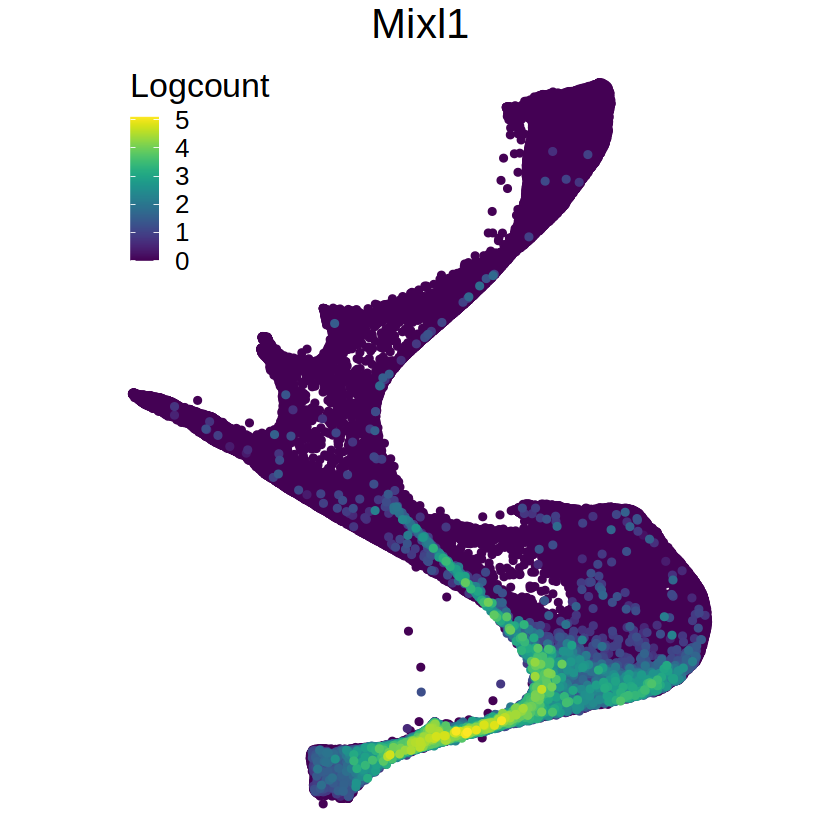

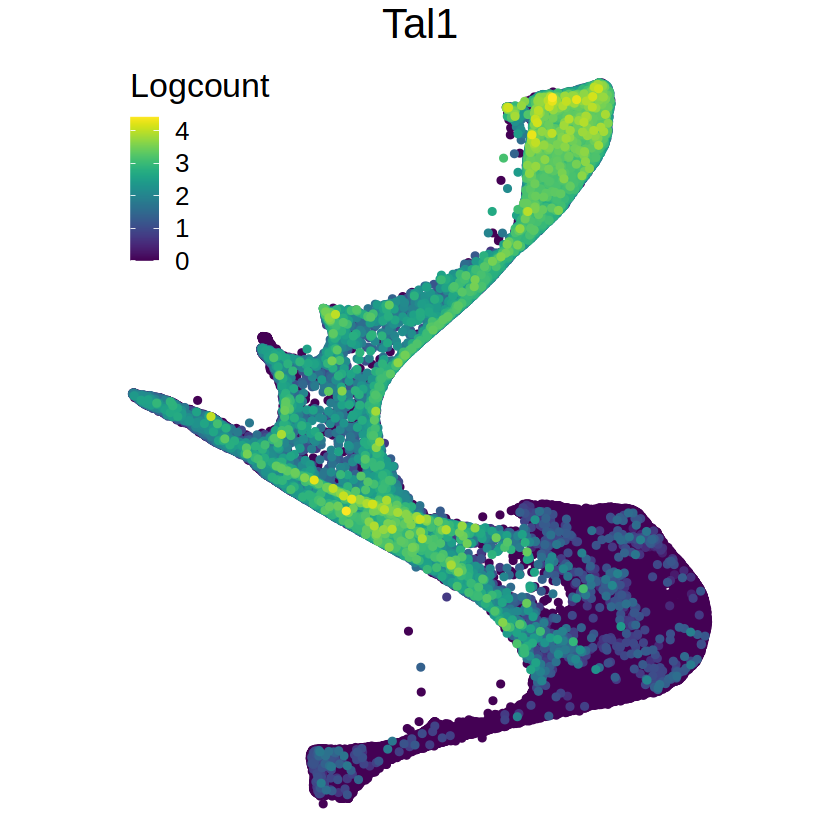

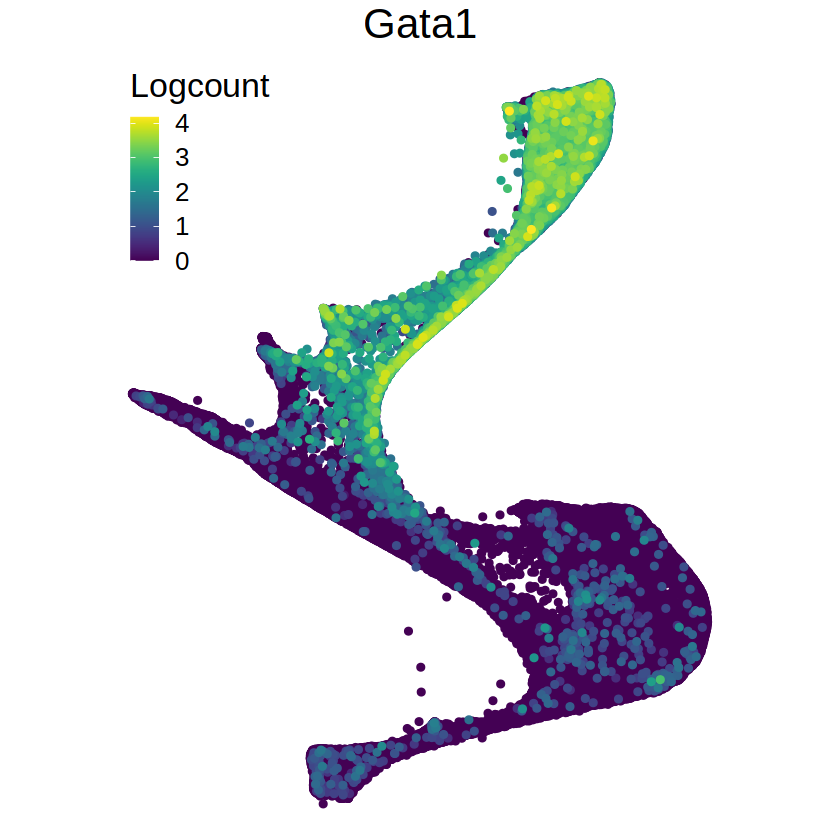

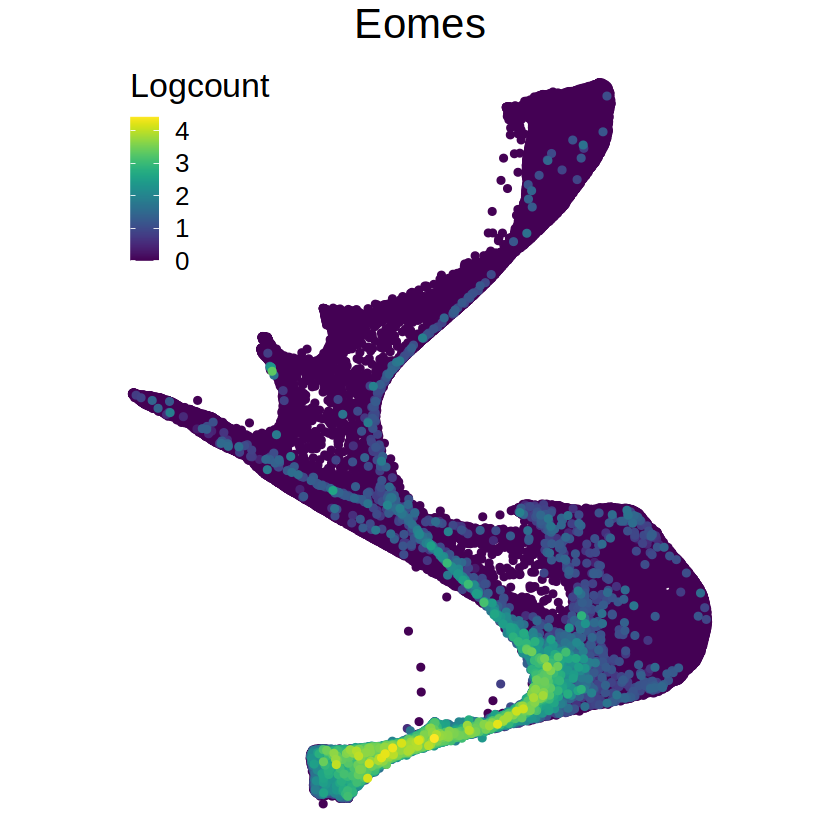

In [57]:
plot_gene('T')
plot_gene('Mixl1')
plot_gene('Tal1')
plot_gene('Gata1')
plot_gene('Eomes')